In [ ]:
# Install Sastrawi library
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

## **LOAD DATA**

In [ ]:
url = 'https://raw.githubusercontent.com/stfnghr/Surabaya-Station-Data-Acquisition-BDA/main/Dataset_Review_Stasiun_Surabaya_RAW.csv'

df = pd.read_csv(url)
df.head()

,Station Name,Reviewer Name,Rating Star,Review Text,Review Date,User Contribution Level
0,Surabaya Pasarturi,kurniawan dwi,5,NaN,2026-05-05T11:14:01.306Z,22
1,Surabaya Pasarturi,Muhammad Ricky Perdana Putra,5,Habis dari Gresik - Indro mampir ke sini karen...,2026-05-05T01:52:54.829Z,28
2,Surabaya Pasarturi,Yudi Cak Gandoz,5,"Stasiun legend,, kalau gak bawa mobil jemputan...",2026-05-04T09:14:26.524Z,69
3,Surabaya Pasarturi,Ardhana mita5,1,Tempat tunggu tidak nyaman berbeda sekali deng...,2026-05-03T17:20:21.556Z,4
4,Surabaya Pasarturi,Mukti Abadi Falah,5,NaN,2026-05-03T14:07:00.653Z,6


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13962 entries, 0 to 13961
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Station Name             13962 non-null  object
 1   Reviewer Name            13962 non-null  object
 2   Rating Star              13962 non-null  int64 
 3   Review Text              6445 non-null   object
 4   Review Date              13962 non-null  object
 5   User Contribution Level  13962 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 654.6+ KB


In [ ]:
df.describe()

,Rating Star,User Contribution Level
count,13962.000000,13962.000000
mean,4.607506,94.950437
std,0.848833,183.849163
min,1.000000,0.000000
25%,5.000000,6.000000
50%,5.000000,28.000000
75%,5.000000,103.000000
max,5.000000,4640.000000


In [ ]:
print(df.shape)

(13962, 6)


In [ ]:
# Check for NaN values
df.isna().sum()

,0
Station Name,0
Reviewer Name,0
Rating Star,0
Review Text,7517
Review Date,0
User Contribution Level,0


In [ ]:
# Nilai tiap column

for col in df.columns:
    print(f"=== {col} ===")
    print(df[col].value_counts(dropna=False))
    print("\n")

=== Station Name ===
Station Name
Stasiun Lama Gubeng    10000
Surabaya Pasarturi      2917
Surabaya Kota            771
Stasiun Wonokromo        274
Name: count, dtype: int64


=== Reviewer Name ===
Reviewer Name
Fathur Rohman                4
Eko Sutiyono                 4
Fery Yandoko                 4
Agus Riyanto                 4
Franky Nugroho               4
                            ..
SRI BINTANG PERDANA PUTRA    1
Demus Silla                  1
Lukman Tamboje               1
Zutien -                     1
Muh. Izzat Ubaidi            1
Name: count, Length: 13471, dtype: int64


=== Rating Star ===
Rating Star
5    10482
4     2437
3      494
1      408
2      141
Name: count, dtype: int64


=== Review Text ===
Review Text
NaN                                                                                                                                                                                                                                                            

In [ ]:
print(df.columns.tolist())

['Station Name', 'Reviewer Name', 'Rating Star', 'Review Text', 'Review Date', 'User Contribution Level']


# **CLEANING**

In [ ]:
print(f"Total baris awal: {len(df)}")

Total baris awal: 13962


In [ ]:
df_clean = df.copy()

In [ ]:
# 1.  Drop Missing Values pada kolom 'Review Text'
df_clean = df.dropna(subset=['Review Text']).copy()
print(f"Baris setelah membuang ulasan kosong (NaN): {len(df_clean)}")

Baris setelah membuang ulasan kosong (NaN): 6445


In [ ]:
# 2. Merapikan Format Tanggal
df_clean['Review Date'] = pd.to_datetime(df_clean['Review Date']).dt.date

In [ ]:
# 3. Satukan Fungsi Advanced Cleaning & Basic Cleansing
def clean_text_advanced(text):
    text = str(text).lower() # Case folding
    text = re.sub(r'\n|\r', ' ', text) # Hapus enter ganti spasi
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text, flags=re.MULTILINE) # Hapus URL
    text = re.sub(r'\S+@\S+', ' ', text) # Hapus Email
    text = re.sub(r'[^a-zA-Z\s\.]', ' ', text)

    # Hapus spasi ganda akibat clean sbelumnya
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
# 4. Pakai fungsi cleaning
df_clean['Review Text'] = df_clean['Review Text'].apply(clean_text_advanced)

In [ ]:
# 5. Fungsi untuk menormalisasi huruf yang berulang atau spam (baguuuus -> bagus)

df_clean['Has_Repetitive_Chars'] = df_clean['Review Text'].apply(lambda x: bool(re.search(r'(.)\1{2,}', str(x))))
jumlah_spam_huruf = df_clean['Has_Repetitive_Chars'].sum()

print(f"Jumlah spam huruf: {jumlah_spam_huruf}")

def normalize_repetitive(text):
    return re.sub(r'(.)\1{2,}', r'\1', str(text))

df_clean['Review Text'] = df_clean['Review Text'].apply(normalize_repetitive)

df_clean = df_clean.drop(columns=['Has_Repetitive_Chars'])

Jumlah spam huruf: 527


In [ ]:
# 6. Hapus string kosong yang muncul akibat penghapusan simbol/emoji
df_clean['Review Text'] = df_clean['Review Text'].replace('', pd.NA)
df_clean = df_clean.dropna(subset=['Review Text'])

In [ ]:
# 7. Hapus Duplikasi Teks
df_clean = df_clean.drop_duplicates(subset=['Review Text'], keep='first')
print(f"Baris setelah membuang duplikasi: {len(df_clean)}")

Baris setelah membuang duplikasi: 5597


In [ ]:
# 8. Filter Ulasan Pendek (< 3 Kata)
df_clean = df_clean[df_clean['Review Text'].str.split().str.len() >= 3]
print(f"Baris akhir setelah membuang ulasan pendek (< 3 kata): {len(df_clean)}")

# Tampilkan hasil akhir
print(f"Baris akhir setelah seluruh proses cleaning yang benar: {len(df_clean)}")

Baris akhir setelah membuang ulasan pendek (< 3 kata): 4976
Baris akhir setelah seluruh proses cleaning yang benar: 4976


In [ ]:
df_clean.head()

,Station Name,Reviewer Name,Rating Star,Review Text,Review Date,User Contribution Level
1,Surabaya Pasarturi,Muhammad Ricky Perdana Putra,5,habis dari gresik indro mampir ke sini karena ...,2026-05-05,28
2,Surabaya Pasarturi,Yudi Cak Gandoz,5,stasiun legend kalau gak bawa mobil jemputan m...,2026-05-04,69
3,Surabaya Pasarturi,Ardhana mita5,1,tempat tunggu tidak nyaman berbeda sekali deng...,2026-05-03,4
6,Surabaya Pasarturi,AJ,5,nice clean place with lots of food choices. th...,2026-05-03,38
7,Surabaya Pasarturi,Dhani Widjayadi,5,untuk kebersihan stasiun pasar turi sudah cuku...,2026-05-03,54


In [ ]:
df_clean.isna().sum()

,0
Station Name,0
Reviewer Name,0
Rating Star,0
Review Text,0
Review Date,0
User Contribution Level,0


In [ ]:
# output_file = 'CLEAN_DATA.csv'
# df_clean.to_csv(output_file, index=False)
# print(f"\nProses Cleaning Selesai! Data disimpan sebagai: {output_file}")

# **NLP (Labeling & Sastrawi)**

### LABELING

In [ ]:
# 1. Buat aturan pelabelan (Labeling Rules)
def tentukan_sentimen(rating):
    if rating >= 4:
        return 1  # 1 = Sentimen Positif
    else:
        return 0  # 0 = Sentimen Negatif

In [ ]:
# 2. Eksekusi pelabelan dan simpan di kolom baru bernama 'Label'
df_clean['Label'] = df_clean['Rating Star'].apply(tentukan_sentimen)

In [ ]:
# 3. Tampilkan distribusi hasil pelabelan
print("=== Distribusi Kelas Sentimen ===")
distribusi = df_clean['Label'].value_counts()
print(f"Sentimen Positif (1) : {distribusi[1]} ulasan")
print(f"Sentimen Negatif (0) : {distribusi[0]} ulasan")

print("\n=== Persentase Data ===")
persentase = df_clean['Label'].value_counts(normalize=True) * 100
print(f"Positif : {persentase[1]:.2f}%")
print(f"Negatif : {persentase[0]:.2f}%\n")

=== Distribusi Kelas Sentimen ===
Sentimen Positif (1) : 4329 ulasan
Sentimen Negatif (0) : 647 ulasan

=== Persentase Data ===
Positif : 87.00%
Negatif : 13.00%



In [ ]:
# 4. Tampilkan 5 data pertama untuk memastikan posisinya benar
print("=== Preview Data (Rating dan Label) ===")
df_clean[['Reviewer Name', 'Rating Star', 'Label', 'Review Text']].head()

=== Preview Data (Rating dan Label) ===


,Reviewer Name,Rating Star,Label,Review Text
1,Muhammad Ricky Perdana Putra,5,1,habis dari gresik indro mampir ke sini karena ...
2,Yudi Cak Gandoz,5,1,stasiun legend kalau gak bawa mobil jemputan m...
3,Ardhana mita5,1,0,tempat tunggu tidak nyaman berbeda sekali deng...
6,AJ,5,1,nice clean place with lots of food choices. th...
7,Dhani Widjayadi,5,1,untuk kebersihan stasiun pasar turi sudah cuku...


### SASTRAWI

In [ ]:
import pandas as pd
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from tqdm import tqdm
tqdm.pandas()

In [ ]:
# 1. Siapkan Mesin Sastrawi (Stopwords & Stemmer)
print("Memuat kamus Stopwords dan Stemmer Sastrawi...")
stopword_factory = StopWordRemoverFactory()
stopwords = stopword_factory.get_stop_words()

Memuat kamus Stopwords dan Stemmer Sastrawi...


In [ ]:
# 2. Tambahkan kata-kata singkatan khas netizen ke dalam daftar stopwords
tambahan_stopwords = ['yg', 'utk', 'dgn', 'nya', 'aja', 'sih', 'kok', 'deh', 'kalo', 'ga', 'gak']
stopwords.extend(tambahan_stopwords)

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

In [ ]:
# 3. Buat fungsi inti pemrosesan NLP
def preprocess_nlp(text):
    # a. Pisahkan kalimat jadi kata per kata, lalu buang yang termasuk stopwords
    words = str(text).split()
    words_filtered = [word for word in words if word not in stopwords]
    text_filtered = ' '.join(words_filtered)

    # b. Ubah kata-kata yang tersisa menjadi kata dasar (Stemming)
    text_stemmed = stemmer.stem(text_filtered)
    return text_stemmed

In [ ]:
# 4. Eksekusi fungsi ke dataset
print("Memulai proses Stopword Removal & Stemming (Ini memakan waktu beberapa menit)...")
df_clean['Clean_Text_NLP'] = df_clean['Review Text'].progress_apply(preprocess_nlp)

Memulai proses Stopword Removal & Stemming (Ini memakan waktu beberapa menit)...


100%|██████████| 4976/4976 [09:55<00:00,  8.36it/s]


In [ ]:
# 5. Pembersihan Akhir (Hapus baris yang mungkin jadi kosong setelah Sastrawi)
df_clean['Clean_Text_NLP'] = df_clean['Clean_Text_NLP'].replace('', pd.NA)
df_clean = df_clean.dropna(subset=['Clean_Text_NLP'])

In [ ]:
# 6. Lihat perbandingan Before-After (Sangat bagus untuk Screenshot Laporan!)
print("\n=== HASIL BEFORE vs AFTER ===")
print(df_clean[['Review Text', 'Clean_Text_NLP']].head())


=== HASIL BEFORE vs AFTER ===
                                         Review Text  \
1  habis dari gresik indro mampir ke sini karena ...   
2  stasiun legend kalau gak bawa mobil jemputan m...   
3  tempat tunggu tidak nyaman berbeda sekali deng...   
6  nice clean place with lots of food choices. th...   
7  untuk kebersihan stasiun pasar turi sudah cuku...   

                                      Clean_Text_NLP  
1  habis gresik indro mampir sini dekat ampel lua...  
2  stasiun legend kalau bawa mobil jemput mending...  
3  tempat tunggu nyaman beda sekali stasiun utama...  
6  nice clean place with lots of food choices the...  
7  bersih stasiun pasar turi cukup bagus kalau ti...  


In [ ]:
# # 7. Simpan hasil akhirnya
# nama_file = 'DATASET_NLP_READY.csv'
# df_clean.to_csv(nama_file, index=False)
# print(f"\nProses NLP Selesai! File tersimpan sebagai '{nama_file}'")

# **Metode TF-IDF & SVM**

In [ ]:
# 1. Pisahkan Teks (X) dan Target/Label (y)
X_text = df_clean['Clean_Text_NLP'].astype(str)
y_label = df_clean['Label']

In [ ]:
# 2. SPLIT DATA TERLEBIH DAHULU (Anti Data Leakage)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y_label, test_size=0.2, random_state=42, stratify=y_label
)

In [ ]:
# 3. EKSTRAKSI FITUR (N-GRAMS)
# ngram_range=(1, 2) artinya mesin belajar 1 kata (Unigram) dan kombinasi 2 kata (Bigram)
# max_features dinaikkan ke 5000 untuk menampung kombinasi 2 kata tersebut
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)

# Fit HANYA pada data training, lalu transform ke training & testing
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)
print(f"Bentuk matriks TF-IDF Training: {X_train.shape} (Mempelajari kombinasi 1 & 2 kata)\n")

Bentuk matriks TF-IDF Training: (3980, 5000) (Mempelajari kombinasi 1 & 2 kata)



In [ ]:
# 4. HYPERPARAMETER TUNING (GridSearchCV)
# Mesin akan mencari setelan nilai 'C' (Penalti Kesalahan) yang paling optimal
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear'],
    'class_weight': ['balanced']
}

print("Memulai pencarian Hyperparameter... (Mohon tunggu, ini melakukan beberapa kali training silang/Cross-Validation)")
# cv=5 artinya membagi data training jadi 5 lipatan untuk diuji secara internal
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Tampilkan parameter juara
best_model = grid_search.best_estimator_
print(f"\nTuning Selesai! Parameter Mesin Terbaik yang ditemukan: {grid_search.best_params_}\n")

Memulai pencarian Hyperparameter... (Mohon tunggu, ini melakukan beberapa kali training silang/Cross-Validation)
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Tuning Selesai! Parameter Mesin Terbaik yang ditemukan: {'C': 1, 'class_weight': 'balanced', 'kernel': 'linear'}



In [ ]:
# 5. Performance Evaluation
y_pred = best_model.predict(X_test)
print("HASIL EVALUASI MODEL OPTIMAL (PEAK PERFORMANCE)")

akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Keseluruhan: {akurasi * 100:.2f}%\n")

print("Laporan Klasifikasi Detail:")
print(classification_report(y_test, y_pred, target_names=['Negatif (0)', 'Positif (1)']))

HASIL EVALUASI MODEL OPTIMAL (PEAK PERFORMANCE)
Akurasi Keseluruhan: 87.04%

Laporan Klasifikasi Detail:
              precision    recall  f1-score   support

 Negatif (0)       0.50      0.65      0.57       129
 Positif (1)       0.95      0.90      0.92       866

    accuracy                           0.87       995
   macro avg       0.72      0.78      0.74       995
weighted avg       0.89      0.87      0.88       995




Visualisasi Confusion Matrix berhasil disimpan sebagai 'Confusion_Matrix_SVM_Optimal.png'


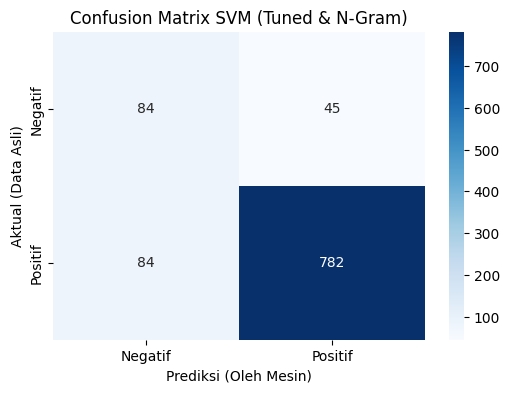

In [ ]:
# 6. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix SVM (Tuned & N-Gram)')
plt.xlabel('Prediksi (Oleh Mesin)')
plt.ylabel('Aktual (Data Asli)')

plt.savefig('Confusion_Matrix_SVM_Optimal.png', dpi=300, bbox_inches='tight')
print("\nVisualisasi Confusion Matrix berhasil disimpan sebagai 'Confusion_Matrix_SVM_Optimal.png'")